# Text Analytics
## Assignment on Transformers

- Georgios Boufis, *f3352504*, *geo.boufis@aueb.gr*
- Leonidha Mara, *f3352514*, *leo.mara@aueb.gr*

In [1]:
# Installing wget to download files and gensim for word embeddings
!pip install --upgrade wget --quiet
! pip install gensim

  Preparing metadata (setup.py) ... done


In [2]:
%pip install --upgrade gensim numpy umap-learn matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 63.3 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.8 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install -U transformers datasets peft evaluate seqeval accelerate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 412.9 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 8.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 8.7 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 8.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.8 MB/s eta 0:00:0000:0100:01
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=b0e4ec7917af7f9233422e66cd4b8661af8ca5fbc0ab136f0d9995ce2e5fa1f3
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-

In [4]:
import copy
import time
import random
import numpy as np
import pandas as pd
import torch
import transformers
from itertools import product
from functools import partial
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    accuracy_score, precision_recall_curve, auc,
    confusion_matrix
)
from datasets import Dataset, DatasetDict

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)


cuda


### Dataset Loading

We are using the IMDb Movie Reviews dataset for sentiment analysis. Here we download the data, extracts it and load it to our environment.

In [6]:
import os

os.system("wget http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz")
os.system("tar -xzf aclImdb_v1.tar.gz")

# Επιβεβαίωση:
print(os.listdir("aclImdb/"))

--2026-03-18 20:47:58--  http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

     0K .......... .......... .......... .......... ..........  0%  657K 2m5s
    50K .......... .......... .......... .......... ..........  0%  655K 2m5s
   100K .......... .......... .......... .......... ..........  0% 1.28M 1m44s
   150K .......... .......... .......... .......... ..........  0%  656K 1m49s
   200K .......... .......... .......... .......... ..........  0% 1.28M 1m40s
   250K .......... .......... .......... .......... ..........  0%  212M 83s
   300K .......... .......... .......... .......... ..........  0% 1.28M 80s
   350K .......... .......... .......... .......... ..........  0% 1.28M 78s
   400K .......... .......

['README', 'imdb.vocab', 'test', 'imdbEr.txt', 'train']


### Loading IMDb Dataset
In this block we load the IMDb movie reviews dataset from local files. We use **sklearn.datasets.load_files()** to load reviews from the 'neg' (negative) and 'pos' (positive) directories in both the train and test folders. The dataset is organized as:
1. **Train set**: Contains labeled reviews from aclImdb/train/neg and aclImdb/train/pos
2. **Test set**: Contains labeled reviews from aclImdb/test/neg and aclImdb/test/pos
Then, we combine the training and test data into unified lists **x (texts)** and **y (labels)** to perform custom train/validation/test splitting later

In [7]:
# Loading the files from the 'neg' and 'pos' directories
train = load_files("aclImdb/train", categories=['neg', 'pos'], encoding="utf-8")
test  = load_files("aclImdb/test",  categories=['neg', 'pos'], encoding="utf-8")

# Combining them to create a full dataset for custom splitting later
x = list(train.data) + list(test.data)
y = list(train.target) + list(test.target)


Here, we print the classes, which are the 'neg' (negative) class and the 'pos' (positive) class as we mentioned before.

In [8]:
print(train.target_names)

['neg', 'pos']


Now, we print the first sample and target to see the structure of the raw text and each label. From the output, reading the text we understand that the review of the specific movie is positive

In [9]:
# First sample and target
print(f'Sample: {x[0]} \nTarget: {y[0]}')


Sample: Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mutual world via coupled destruction.<br /><br />It is not a perfect movie but given what money/time the filmmaker and actors had - it is a remarkable product. In terms of explaining the motives and actions of the two young suicide/murderers it is better than 'Elephant' - in terms of being a film that gets under our 'rationalistic' skin it is a far, far better film than almost anything you are likely to see. <br /><br />Flawed but honest with a terrible honesty. 
Target: 1


**Data Visualization**

Total Dataset Size: We have a total of 50,000 reviews, which is a large enough sample to train a reliable model.

Perfect Balance: The dataset is perfectly split with 25,000 negative (50%) and 25,000 positive (50%) reviews. This is great because the model won't be biased toward one specific sentiment.

Review Length Variation: * Reviews vary a lot in size. The shortest is only 4 words, while the longest reaches 2,470 words.

Our mean is 231.2 words while the median is only 173.0. In a symmetrical distribution, these would be the same. Since the mean is significantly higher, it shows the average is being pulled to the right by very long reviews.

We have a maximum length of 2,470 words, which is huge compared to the median. These long reviews form the "long tail" on the right side of the histogram.

Most reviews are concentrated on the shorter end (near the 173-word mark), while the distribution stretches out much further toward the higher word counts.

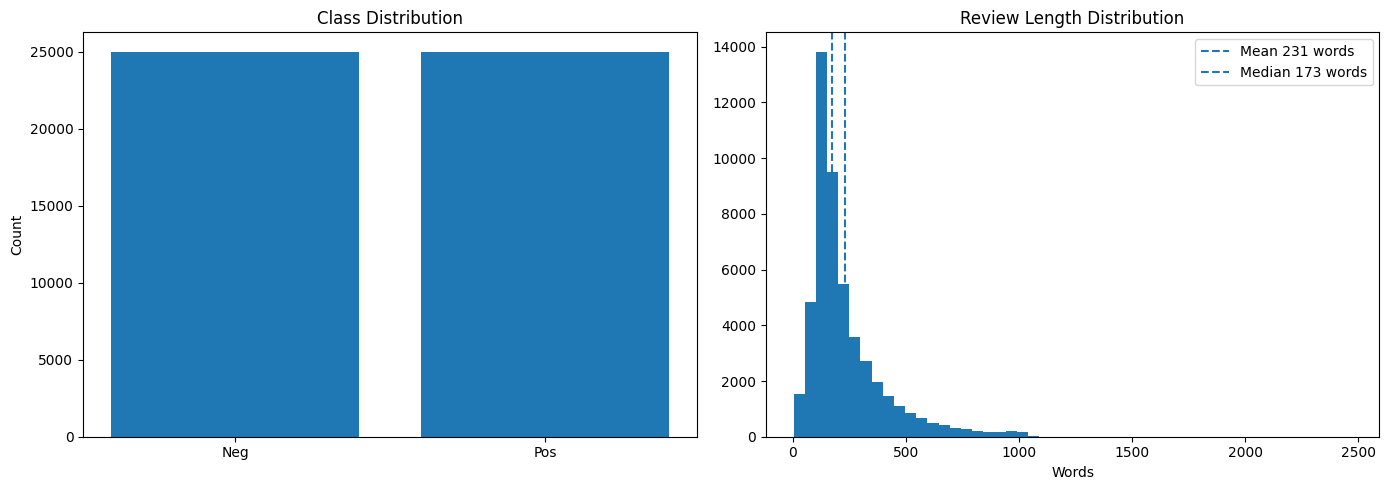


Total Reviews: 50000
Neg: 25000 (50.0%)
Pos: 25000 (50.0%)

Length stats:
Min: 4
Max: 2470
Mean: 231.2
Median: 173.0
Std: 171.3



In [10]:
# Visualizing how many reviews we have per class and their word counts
counts = np.bincount(y)
lengths = [len(r.split()) for r in x]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
ax[0].bar(range(len(counts)), counts)
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels(['Neg', 'Pos'])
ax[0].set_title("Class Distribution")
ax[0].set_ylabel("Count")

# Review length distribution
ax[1].hist(lengths, bins=50)
ax[1].axvline(np.mean(lengths), linestyle="--", label=f"Mean {np.mean(lengths):.0f} words")
ax[1].axvline(np.median(lengths), linestyle="--", label=f"Median {np.median(lengths):.0f} words")
ax[1].set_title("Review Length Distribution")
ax[1].set_xlabel("Words")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"""
Total Reviews: {len(x)}
Neg: {counts[0]} ({counts[0]/len(x)*100:.1f}%)
Pos: {counts[1]} ({counts[1]/len(x)*100:.1f}%)

Length stats:
Min: {min(lengths)}
Max: {max(lengths)}
Mean: {np.mean(lengths):.1f}
Median: {np.median(lengths):.1f}
Std: {np.std(lengths):.1f}
""")

### Dataset Length Statistics
This block analyzes the length distribution of reviews in the dataset. We compute the word count for each review by splitting on whitespace and calculating statistics (mean, max, min, median) separately for the train and test portions of our conbined dataset.
BERT has a maximum sequence length of 512 tokens, reviews longer than this will need to be truncated. Also, understanding length distribution helps with preprocessing decisions, we need to know if truncation will significantly affect the data.
Finally, length affects model training, very short or very long sequences may impact performance differently.
From the result we observe that the **average review length** is almost 231 words in train set and 115 words in test set. The **max review length** is 2.470 words for train and 2.278 for test, this exceeds BERT's 512 token limit, so truncation will be necessary.
**Min review length** is 4-10 words and **median length** is almost 173 words.

In [11]:
# Length of reviews
train_lengths = [len(str(review).split()) for review in x[:25000]]
test_lengths = [len(str(review).split()) for review in x[25000:]]


print(f"Train - Average length: {np.mean(train_lengths):.1f}, Max: {np.max(train_lengths)}, Min: {np.min(train_lengths)}, Media: {np.median(train_lengths)}")
print(f"Test - Average length: {np.mean(test_lengths):.1f}, Max: {np.max(test_lengths)}, Min: {np.min(test_lengths)}, Media: {np.median(test_lengths)}")


Train - Average length: 233.8, Max: 2470, Min: 10, Media: 174.0
Test - Average length: 228.5, Max: 2278, Min: 4, Media: 172.0


### Data Structure 

Here, we perform basic sanity check on the loaded dataset to verify data integrity and structure. We inspect:
1. Data types: confirming that x (texts) and y (labels) are stored as Python lists.
2. Dataset size: Verifying that we have equal numbers of reviews and labels.
3. Sample inspection: Displaying the first 100 characters of the first review and its corresponding label.

So, we have that:
1. x is a list of text strings, y is a list of integer labels.
2. Dataset is balanced: 50.000 total samples with matching texts and labels, 25.000 negative reviews (label 0) and 25.000 positive reviews (label 1)
3.  First sample inspection: Text content properly loaded and label is correclty assigned.

In [ ]:
print(f"Type of x: {type(x)}")
print(f"Length of x: {len(x)}")
print(f"Type of y: {type(y)}")
print(f"Length of y: {len(y)}")
print(f"\nFirst element of x: {x[0][:100]}...")  
print(f"First element of y: {y[0]}")

Type of x: <class 'list'>
Length of x: 50000
Type of y: <class 'list'>
Length of y: 50000

First element of x: Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mu...
First element of y: 1


### Train/Validation/Test split with Stratification

This block performs a two-stage stratified train/validation/test split to create three disjoint subsets for model development and evaluation:
1. First split (90/10): Divides data into 90% for training/validation and 10% for final testing.
2. Second split (80/20): Divides the 90% into 80% for training and 20% for validation/development.

Stratification ensures that both the negative and positive class distributions are preserved in each split, preventing class imbalance issues that could bias model evaluation.
So, the final split ratios:
* Training: 72% (36.000 samples)
* Development/Validation: 18% (9.000 samples)
* Test: 10% (5.000 samples)

We use random_state=42 for reproducibility, ensuring consistent results across different runs.

We observe that class balance preserved across all splits:
* Train: 18,000 negative (50%) + 18,000 positive (50%)
* Dev: 4,500 negative (50%) + 4,500 positive (50%)
* Test: 2,500 negative (50%) + 2,500 positive (50%)

In [13]:
print(f"Total reviews: {len(x)}, Total labels: {len(y)}")

# First split: 90% for train/val, 10% for final test
X_temp, X_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.1,
    random_state=42,
    stratify=y
)

# Second split: 80/20 of the 90% → train/dev
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp, test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain: {len(X_train)}, Dev: {len(X_dev)}, Test: {len(X_test)}")
print(f"Train labels - Neg(0): {sum(1 for label in y_train if label==0)}, Pos(1): {sum(1 for label in y_train if label==1)}")
print(f"Dev labels - Neg(0): {sum(1 for label in y_dev if label==0)}, Pos(1): {sum(1 for label in y_dev if label==1)}")
print(f"Test labels - Neg(0): {sum(1 for label in y_test if label==0)}, Pos(1): {sum(1 for label in y_test if label==1)}")

Total reviews: 50000, Total labels: 50000

Train: 36000, Dev: 9000, Test: 5000
Train labels - Neg(0): 18000, Pos(1): 18000
Dev labels - Neg(0): 4500, Pos(1): 4500
Test labels - Neg(0): 2500, Pos(1): 2500


### Converting to Hugging Face Dataset Format

This block converts our plain Python lists into Huggin Face Dataset objects, which are optimized for working with transformer models. We create three separate Dataset objects for train, validation and test splits, each containing two columns:
1. 'text': The review text
2. 'label': The binary sentiment label (0 or 1)

We then combine these into a DatasetDict, a dictionary like structure that holds all three splits together. This format is required by the Hugging Face Trainer API for streamlined model training and evaluation.
Hugging Face Datasets have:
* Efficient data handling: optimized for large datasets with efficient memory usage
* Integration with Transformers: Seamlessly works with the Trainer and tokenization utilities
* Batch processing: Supports efficient batching during training
* Consistency: Standard format across the Hugging Face ecosystem

In [14]:
# Create Hugging Face Datasets
train_dataset = Dataset.from_dict({
    'text': X_train,
    'label': y_train
})

dev_dataset = Dataset.from_dict({
    'text': X_dev,
    'label': y_dev
})

test_dataset = Dataset.from_dict({
    'text': X_test,
    'label': y_test
})

# Create DatasetDict
dataset = DatasetDict({
    'train': train_dataset,
    'validation': dev_dataset,
    'test': test_dataset
})

print(dataset)
print(dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 36000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 9000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 5000
    })
})
{'text': 'Daniel Day-Lewis is Christy Brown, a victim of cerebral palsy who uses "My Left Foot" to write and paint in this incredible 1989 film. The movie also stars Brenda Fricker as Christy\'s mother, Ray McAnally, Fiona Shaw and Hugh O\'Conor. Their brilliant performances, great script and wonderful direction by Jim Sheridan help to paint a vivid portrait of Christy Brown, an artist and writer who died in 1981 at the age of 49.<br /><br />Brown was born into a lower middle-class Catholic family where his mother was constantly pregnant (22 children in total, 13 of whom survived). His father considered Christy mentally retarded as well as physically handicapped, but he would not permit his son to go into

### BERT Tokenization and Preprocessing

This block tokenizes all reviews in the dataset using the BERT tokenizer. The process converts raw text into numerical IDs that BERT can process.

1. **Tokenizer loading**: **AutoTokenizer.from_pretrained("bert-base-uncased")** loads the official BERT vocabulary and tokenization rules.
2. **Tokenization function**: **prepare_dataset()** applies the tokenizer with:
     *  truncation=True: cuts sequences longer than 512 tokens (BERT's max length)
     *  max_length=512: sets the maximum sequence length
     *  padding=True: Pads shorter sequences to 512 tokens with [PAD] tokens
3. **Batch processing**: .map(..., batched=True): efficiently tokenizes all samples



Output fields for each sample are:
1. input_ids: numerical tokens IDs (512 per sample)
2. token_type_ids: seqment IDs (0 for single-sentence tasks)
3. attention_mask: Binary mask (1=real token, 0=padding)

In [15]:
# Load BERT tokenizer
tokenizer = transformers.AutoTokenizer.from_pretrained("bert-base-uncased")

# Define tokenization function
def prepare_dataset(examples, tokenizer):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=512
    )

# Apply to the dataset
tokenized_dataset = dataset.map(
    partial(prepare_dataset, tokenizer=tokenizer),
    batched=True
)

print(tokenized_dataset)
print("\nFirst sample:")
print(tokenized_dataset['train'][0])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

Map:   0%|          | 0/9000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 36000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})

First sample:
{'text': 'Daniel Day-Lewis is Christy Brown, a victim of cerebral palsy who uses "My Left Foot" to write and paint in this incredible 1989 film. The movie also stars Brenda Fricker as Christy\'s mother, Ray McAnally, Fiona Shaw and Hugh O\'Conor. Their brilliant performances, great script and wonderful direction by Jim Sheridan help to paint a vivid portrait of Christy Brown, an artist and writer who died in 1981 at the age of 49.<br /><br />Brown was born into a lower middle-class Catholic family where his mother was constantly pregnant (22 chil

### Removing Unnecessary Columns
This block removes the original 'text' column from the tokenized dataset since it's no longer needed. After tokenization, we have:
* input_ids: Token IDs (512 per sample)
* attention_mask: Attention mask (512 per sample)
* token_type_ids: Segment IDs (512 per sample)
* label: Binary sentiment label
* text: Original review text

Removing the 'text' column saves memory during training since:
1. The text is already converted to tokens
2. The original text takes up significant RAM space
3. The model only needs token IDs not the original text.

To conclude, removing redundant 'text' column we optimize the memory, the essential fields retained like input_ids, attention_mask, token_type_ids, label.
Now contains only necessary features for BERT.

In [16]:
# Remove text fields, we don't need them for the training
tokenized_dataset = tokenized_dataset.remove_columns(['text'])

print(tokenized_dataset)
print(tokenized_dataset['train'][0].keys())

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 36000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})
dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


### Label Mapping Definition

Now, we create bidirectional mappings between numerical labels and their semantic meanings:
1. id2label: Maps numerical IDs to huma-readable class names
2. label2id: Maps class names back to numerical IDs

In [17]:
# Define id2label and label2id mappings
id2label = {0: "Negative", 1: "Positive"}
label2id = {"Negative": 0, "Positive": 1}

### Metrics Computation Function

We define **compute_metrics()**, a function that calculates evaluation metrics during model training. The Hugging Face Trainer calls this function after each validation step to monitor model performance.

First, extract predictions and labels, unpacks the evaluation predictions. Then, convert logits to class predictions using argmax() to select the class with highest probability (0 or 1).
Finally, calculate metrics, accuracy, precision, recall, F1-score.
Macro-averaging: computes metrics for each class separately, then takes the unweighted mean.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    
    # Macro-averaged metrics 
    accuracy = np.sum(predictions == labels) / len(labels)
    precision = precision_score(labels, predictions, average="macro", zero_division=0)
    recall = recall_score(labels, predictions, average="macro", zero_division=0)
    f1 = f1_score(labels, predictions, average="macro", zero_division=0)
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### DataCollator Configuration
This block creates a DataCollatorWithPadding object that handles dynamic padding during training. A data collator is responsible for preparing batches of data for the model.

**Dynamic padding**: Pads sequences to the longest sequence in each batch. It is more efficient than padding everything to 512 tokens, reduces computational waste on shorter sequences and each batch is padded to its own max length, and not a global maximum.

**Batch assembly**: collects individual samples into batches with consistent shapes

**PyTorch tensor conversion**: return_tensors="pt" converts data to PyTortch tensors

**Attention mask handling**: automatically creates/ updates attention masks based on padding

In [19]:
data_collator = transformers.DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt") # Dynamically pads the sequences within each batch to avoid any shape misalignments


## Parameter Efficiency with LoRA

The base BERT model contains approximately **109M parameters**.  
After applying LoRA, only **~591K parameters (0.54%)** remain trainable, while the rest are frozen.

This demonstrates the key advantage of LoRA: instead of fine-tuning the entire model, we update only a **very small subset of parameters**, significantly reducing computational cost and memory usage.

Despite training only **0.54% of the parameters**, the model still achieves strong performance on the sentiment classification task, showing that LoRA is a highly **parameter-efficient fine-tuning method**.



In [20]:
print("Base Model - Parameter Statistics")

# Load base model to show parameter count
base_model_temp = transformers.AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

#Count base model parameters
total_params = sum(p.numel() for p in base_model_temp.parameters())

# Create sample LoRA config
lora_config_temp = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

# Apply LoRA
model_lora_temp = get_peft_model(base_model_temp, lora_config_temp)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model_lora_temp.parameters() if p.requires_grad)
trainable_percent = (trainable_params/ total_params) * 100

# Results
print("BERT Base Model")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,} ({trainable_percent:.2f}%)")
print(f"Frozen parameters: {total_params - trainable_params:,}")

print(f"LoRA Fine-Tuning: Only {trainable_percent:.2f}% of parameters will be updated")

# Cleanup
del model_lora_temp, base_model_temp
torch.cuda.empty_cache()

Base Model - Parameter Statistics


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Base Model
Total parameters: 109,483,778
Trainable parameters (LoRA): 591,362 (0.54%)
Frozen parameters: 108,892,416
LoRA Fine-Tuning: Only 0.54% of parameters will be updated


### LoRA Hyperparameter Tuning with Grid Search

This block performs systematic hyperparameter tuning using grid search to identify the optimal LoRA configuration for fine-tuning BERT on the IMDb sentiment classification task.
Grid Search Process:

Configuration Space: Tests 3 combinations of hyperparameters:

1. LoRA rank (r): [8, 16]
2. LoRA alpha (lora_alpha): [32, 64]
3. Fixed parameters: dropout=0.1, learning_rate=1e-3

For each configuration:

1. Loads a fresh BERT base model ("bert-base-uncased")
2. Applies LoRA with the specific hyperparameters to query and value modules
3. Trains on the training set for 1 epoch
4. Evaluates on the development set after training
5. Stores metrics and logs


**Best Model Selection**: Tracks the configuration with the highest F1 score on the development set

**Model Management**:

Saves the best trainer for later evaluation
Clears GPU memory between configurations to prevent memory overflow


**Best Configuration** :

Model: LoRA_Model_3
R = 16 (higher rank captures more task-specific information)
LoRA_Alpha = 32 (optimal scaling factor)
Dropout = 0.1 (prevents overfitting)
Learning_Rate = 0.001 (stable learning)
F1-Score = 0.9347 (excellent performance)
Validation Loss = 0.3702 (low loss)

In [ ]:
import copy
import time
import random
import numpy as np
import pandas as pd
import torch
import transformers
from itertools import product
from peft import LoraConfig, get_peft_model, TaskType

print("LoRA Hyper-parameter Tuning with Grid Search on Dev Set")
print("=" * 100 + "\n")

# GRID SEARCH PARAMETERS 
GRID_PARAMS = {
 "r": [8, 16],
 "lora_alpha": [32, 64],
 "lora_dropout": [0.1],
 "learning_rate": [1e-3]
}

# Generate all combinations
all_combinations = list(product(*GRID_PARAMS.values()))
param_names = list(GRID_PARAMS.keys())

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

selected_combinations = all_combinations[:3] 

# Create CONFIGS
CONFIGS = {}
for idx, combo in enumerate(selected_combinations, 1):
 config_name = f"LoRA_Model_{idx}"
 config_dict = dict(zip(param_names, combo))
 CONFIGS[config_name] = config_dict

print(f"Grid Search: {len(CONFIGS)} configurations\n")
print("Selected Configurations:")
for name, config in CONFIGS.items():
 print(f" {name}: {config}")
print("\n")

EPOCHS = 1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Epochs: {EPOCHS}")
print(f"Testing {len(CONFIGS)} configurations...\n")

# RESULTS
results = {}
best_overall = {
 "key": None,
 "f1_macro": -1.0,
 "val_loss": float("inf"),
 "best_epoch": None,
 "config": None,
 "trainer": None
}

# TUNING LOOP
start_time = time.time()

for model_idx, (model_name, config) in enumerate(CONFIGS.items(), 1):
 print(f"Training {model_name}...")
 print(f"Config: {config}")
 print(f"{'='*60}\n")

 try:

  # Load fresh base model
  base_model = transformers.AutoModelForSequenceClassification.from_pretrained(
   "bert-base-uncased",
   num_labels=2,
   id2label=id2label,
   label2id=label2id
  )

  # Apply LoRA
  lora_config = LoraConfig(
   task_type=TaskType.SEQ_CLS,
   r=config["r"],
   lora_alpha=config["lora_alpha"],
   lora_dropout=config["lora_dropout"],
   target_modules=["query", "value"]
  )

  model_lora = get_peft_model(base_model, lora_config)

  # Training args
  training_args = transformers.TrainingArguments(
   output_dir=f"./{model_name}_results",
   learning_rate=config["learning_rate"],
   per_device_train_batch_size=8,
   per_device_eval_batch_size=8,
   num_train_epochs=EPOCHS,
   weight_decay=0.01,
   eval_strategy="epoch",
   save_strategy="epoch",
   load_best_model_at_end=True,
   metric_for_best_model="f1",
   greater_is_better=True,
   report_to="none",
   seed=42,
   disable_tqdm=False
  )

  # Trainer
  trainer = transformers.Trainer(
   model=model_lora,
   args=training_args,
   train_dataset=tokenized_dataset["train"],
   eval_dataset=tokenized_dataset["validation"],
   data_collator=data_collator,
   compute_metrics=compute_metrics
  )

  # Train
  trainer.train()

  # Extract metrics
  log_history = trainer.state.log_history

  train_losses = []
  val_losses = []
  eval_f1s = []
  eval_epochs = []

  for log in log_history:
   if "loss" in log and "epoch" in log:
    train_losses.append((log["epoch"], log["loss"]))
   if "eval_loss" in log and "epoch" in log:
    val_losses.append((log["epoch"], log["eval_loss"]))
    eval_f1s.append(log.get("eval_f1_macro", None))
    eval_epochs.append(log["epoch"])

  # Best metrics
  best_metric = trainer.state.best_metric if trainer.state.best_metric is not None else (eval_f1s[-1] if eval_f1s else -1)
  best_val_loss = min([x[1] for x in val_losses]) if val_losses else None
  best_epoch = trainer.state.best_model_checkpoint.split("-")[-1] if trainer.state.best_model_checkpoint else None

  # Store results
  results[model_name] = {
   "config": config,
   "f1_macro": best_metric,
   "best_val_loss": best_val_loss,
   "best_epoch": best_epoch,
   "log_history": copy.deepcopy(log_history),
  }

  print(f"F1: {best_metric:.5f}, Val Loss: {best_val_loss:.4f}\n")

  # Track best
  if best_metric > best_overall["f1_macro"]:
   best_overall.update({
    "key": model_name,
    "f1_macro": best_metric,
    "val_loss": best_val_loss,
    "best_epoch": best_epoch,
    "config": copy.deepcopy(config),
    "trainer": trainer
   })
   print(f" New best: {best_metric:.5f}\n")
  else:
   del trainer

  del model_lora, base_model
  torch.cuda.empty_cache()

 except Exception as e:
  print(f"ERROR in {model_name}: {str(e)}")
  torch.cuda.empty_cache()
  continue

total_time = time.time() - start_time

print(f"\n{'='*100}")
print(f"Best Model: {best_overall['key']}")
print(f"F1-Macro: {best_overall['f1_macro']:.4f}")
print(f"Val Loss: {best_overall['val_loss']:.4f}" if best_overall["val_loss"] is not None else "Val Loss: N/A")
print(f"Best Epoch: {best_overall['best_epoch']}")

print(f"\nBest Hyperparameters:")
print(f" r = {best_overall['config']['r']}")
print(f" LoRA_Alpha = {best_overall['config']['lora_alpha']}")
print(f" LoRA_Dropout = {best_overall['config']['lora_dropout']}")
print(f" Learning_Rate = {best_overall['config']['learning_rate']}")

print(f"\nTotal tuning time: {total_time/60:.2f} minutes")
print(f"{'='*100}")

best_trainer = best_overall["trainer"]
best_model = best_trainer.model if best_trainer else None

LoRA Hyper-parameter Tuning with Grid Search on Dev Set

Grid Search: 3 configurations

Selected Configurations:
 LoRA_Model_1: {'r': 8, 'lora_alpha': 32, 'lora_dropout': 0.1, 'learning_rate': 0.001}
 LoRA_Model_2: {'r': 8, 'lora_alpha': 64, 'lora_dropout': 0.1, 'learning_rate': 0.001}
 LoRA_Model_3: {'r': 16, 'lora_alpha': 32, 'lora_dropout': 0.1, 'learning_rate': 0.001}


Device: cuda
Epochs: 1
Testing 3 configurations...

Training LoRA_Model_1...
Config: {'r': 8, 'lora_alpha': 32, 'lora_dropout': 0.1, 'learning_rate': 0.001}



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.431210,0.377492,0.931444,0.931671,0.931444,0.931435


F1: 0.93144, Val Loss: 0.3775

 New best: 0.93144

Training LoRA_Model_2...
Config: {'r': 8, 'lora_alpha': 64, 'lora_dropout': 0.1, 'learning_rate': 0.001}



...

F1: 0.33333, Val Loss: 1.3874

Training LoRA_Model_3...
Config: {'r': 16, 'lora_alpha': 32, 'lora_dropout': 0.1, 'learning_rate': 0.001}



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.427863,0.370178,0.934667,0.934797,0.934667,0.934662


F1: 0.93466, Val Loss: 0.3702

 New best: 0.93466


Best Model: LoRA_Model_3
F1-Macro: 0.9347
Val Loss: 0.3702
Best Epoch: 2250

Best Hyperparameters:
 r = 16
 LoRA_Alpha = 32
 LoRA_Dropout = 0.1
 Learning_Rate = 0.001

Total tuning time: 88.05 minutes


### Re-training Best Model with 2 Epochs

After identifying the optimal hyperparameters through grid search (r=16, alpha=32), we re-train the best model configuration with an increased number of epochs (2 instead of 1) to allow for more thorough learning and better generalization.

1. Load Best Configuration: Extracts the optimal hyperparameters from grid search results

r=16, lora_alpha=32, lora_dropout=0.1, learning_rate=0.001

2. Initialize Fresh Model: Loads a new BERT base model and applies LoRA with best configuration
3. Extended Training: Trains for 2 epochs (vs 1 epoch in grid search) to:

    * Allow more gradient updates
    * Achieve better convergence
    * Improve validation performance
    * Provide more stable final evaluation


4. Same Training Configuration:

   * Batch size: 8
   * Weight decay: 0.01 (L2 regularization)
   * Evaluation strategy: after each epoch
   * Model selection: based on F1 score

| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
| 1 | 0.4961 | 0.4549 | 0.9212 | 0.9227 | 0.9212 | 0.9211 |
| 2 | 0.3208 | 0.4080 | 0.9334 | 0.9334 | 0.9334 | 0.9334 |


In [22]:
print("Re-training Best Model with 2 Epochs")
print("=" * 100 + "\n")

# Best config από grid-search
best_config = best_overall["config"]

# Φόρτωσε νέο model με best config
base_model = transformers.AutoModelForSequenceClassification.from_pretrained(
 "bert-base-uncased",
 num_labels=2,
 id2label=id2label,
 label2id=label2id
)

lora_config = LoraConfig(
 task_type=TaskType.SEQ_CLS,
 r=best_config["r"],
 lora_alpha=best_config["lora_alpha"],
 lora_dropout=best_config["lora_dropout"],
 target_modules=["query", "value"]
)

model_best = get_peft_model(base_model, lora_config)

# Training args με 2 epochs
training_args = transformers.TrainingArguments(
 output_dir="./best_model_results/",
 learning_rate=best_config["learning_rate"],
 per_device_train_batch_size=8,
 per_device_eval_batch_size=8,
 num_train_epochs=2, 
 weight_decay=0.01,
 eval_strategy="epoch",
 save_strategy="epoch",
 load_best_model_at_end=True,
 metric_for_best_model="f1",
 greater_is_better=True,
 report_to="none",
 seed=42
)

# Trainer
trainer_best = transformers.Trainer(
 model=model_best,
 args=training_args,
 train_dataset=tokenized_dataset["train"],
 eval_dataset=tokenized_dataset["validation"],
 data_collator=data_collator,
 compute_metrics=compute_metrics
)

# Train
trainer_best.train()

Re-training Best Model with 2 Epochs



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.496126,0.454905,0.921222,0.922778,0.921222,0.921150
2,0.320832,0.408059,0.933444,0.933458,0.933444,0.933444


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=4500, training_loss=0.45640574137369794, metrics={'train_runtime': 3535.6111, 'train_samples_per_second': 20.364, 'train_steps_per_second': 1.273, 'total_flos': 1.887238274189683e+16, 'train_loss': 0.45640574137369794, 'epoch': 2.0})

## Final Evaluation (Train / Dev / Test)

We evaluate the best fine-tuned BERT model using:
- **Accuracy**
- **Macro Precision, Recall, F1**
- **Macro PR-AUC**

### Results

- **Train:** Accuracy = 0.9629 | F1 = 0.9629 | PR-AUC = 0.9912  
- **Dev:** Accuracy = 0.9334 | F1 = 0.9334 | PR-AUC = 0.9814  
- **Test:** Accuracy = 0.9360 | F1 = 0.9360 | PR-AUC = 0.9835  

---

## Key Observations

- The model achieves **high performance (~93–96%)** across all sets.
- The small drop from train to dev/test (~3%) indicates **good generalization** and no strong overfitting.
- Dev and test results are very close, showing **stable performance**.
- Metrics are **balanced across classes**, meaning no bias toward Positive or Negative.
- High PR-AUC (>0.98) indicates **strong confidence and ranking ability**.

---

## Conclusion

The fine-tuned BERT model is **accurate, stable, and well-balanced**, with strong generalization to unseen data.

In [23]:
print("Final Evaluation on Train / Dev / Test Sets")
print("=" * 100 + "\n")

def evaluate_on_set(trainer, dataset, set_name):
    """Evaluate on a specific dataset and compute all metrics"""
    
    print(f"\nEvaluating on {set_name} set...")
    
    # Get predictions
    predictions = trainer.predict(dataset)
    logits = predictions.predictions
    labels = predictions.label_ids
    
    # Convert logits to class predictions
    pred_classes = np.argmax(logits, axis=1)
    
    # Get probabilities using softmax
    exp_logits = np.exp(logits)
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    
    # Overall accuracy
    accuracy = np.sum(pred_classes == labels) / len(labels)
    
    # Per-class metrics
    precision_per_class = precision_score(labels, pred_classes, average=None, zero_division=0)
    recall_per_class = recall_score(labels, pred_classes, average=None, zero_division=0)
    f1_per_class = f1_score(labels, pred_classes, average=None, zero_division=0)
    
    # Macro-averaged metrics
    precision_macro = precision_score(labels, pred_classes, average="macro", zero_division=0)
    recall_macro = recall_score(labels, pred_classes, average="macro", zero_division=0)
    f1_macro = f1_score(labels, pred_classes, average="macro", zero_division=0)
    
    # PR-AUC per class
    pr_auc_per_class = []
    for class_idx in range(2):
        if class_idx == 0:
            scores = 1 - probs[:, 1]
            binary_labels = (labels == 0).astype(int)
        else:
            scores = probs[:, 1]
            binary_labels = (labels == 1).astype(int)
        
        precision_vals, recall_vals, _ = precision_recall_curve(binary_labels, scores)
        pr_auc = auc(recall_vals, precision_vals)
        pr_auc_per_class.append(pr_auc)
    
    # Macro PR-AUC
    pr_auc_macro = (pr_auc_per_class[0] + pr_auc_per_class[1]) / 2
    
    # Print results
    print(f"\n{set_name.upper()} Set Results:")
    print(f"Accuracy: {accuracy:.4f}\n")
    
    print(f"Per-Class Metrics:")
    print(f" Class 0 (Negative):")
    print(f" Precision: {precision_per_class[0]:.4f}")
    print(f" Recall: {recall_per_class[0]:.4f}")
    print(f" F1: {f1_per_class[0]:.4f}")
    print(f" PR-AUC: {pr_auc_per_class[0]:.4f}")
    
    print(f" Class 1 (Positive):")
    print(f" Precision: {precision_per_class[1]:.4f}")
    print(f" Recall: {recall_per_class[1]:.4f}")
    print(f" F1: {f1_per_class[1]:.4f}")
    print(f" PR-AUC: {pr_auc_per_class[1]:.4f}")
    
    print(f"\nMacro-Averaged Metrics:")
    print(f" Precision (macro): {precision_macro:.4f}")
    print(f" Recall (macro): {recall_macro:.4f}")
    print(f" F1 (macro): {f1_macro:.4f}")
    print(f" PR-AUC (macro): {pr_auc_macro:.4f}")
    
    return {
        "accuracy": accuracy,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "f1_per_class": f1_per_class,
        "pr_auc_per_class": pr_auc_per_class,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "pr_auc_macro": pr_auc_macro,
    }

# Evaluate on all three sets
train_results = evaluate_on_set(trainer_best, tokenized_dataset["train"], "train")
dev_results = evaluate_on_set(trainer_best, tokenized_dataset["validation"], "dev")
test_results = evaluate_on_set(trainer_best, tokenized_dataset["test"], "test")

Final Evaluation on Train / Dev / Test Sets


Evaluating on train set...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



TRAIN Set Results:
Accuracy: 0.9629

Per-Class Metrics:
 Class 0 (Negative):
 Precision: 0.9631
 Recall: 0.9627
 F1: 0.9629
 PR-AUC: 0.9917
 Class 1 (Positive):
 Precision: 0.9627
 Recall: 0.9631
 F1: 0.9629
 PR-AUC: 0.9908

Macro-Averaged Metrics:
 Precision (macro): 0.9629
 Recall (macro): 0.9629
 F1 (macro): 0.9629
 PR-AUC (macro): 0.9912

Evaluating on dev set...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



DEV Set Results:
Accuracy: 0.9334

Per-Class Metrics:
 Class 0 (Negative):
 Precision: 0.9359
 Recall: 0.9307
 F1: 0.9333
 PR-AUC: 0.9826
 Class 1 (Positive):
 Precision: 0.9310
 Recall: 0.9362
 F1: 0.9336
 PR-AUC: 0.9803

Macro-Averaged Metrics:
 Precision (macro): 0.9335
 Recall (macro): 0.9334
 F1 (macro): 0.9334
 PR-AUC (macro): 0.9814

Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



TEST Set Results:
Accuracy: 0.9360

Per-Class Metrics:
 Class 0 (Negative):
 Precision: 0.9360
 Recall: 0.9360
 F1: 0.9360
 PR-AUC: 0.9837
 Class 1 (Positive):
 Precision: 0.9360
 Recall: 0.9360
 F1: 0.9360
 PR-AUC: 0.9832

Macro-Averaged Metrics:
 Precision (macro): 0.9360
 Recall (macro): 0.9360
 F1 (macro): 0.9360
 PR-AUC (macro): 0.9835


## Learning Curves: Training vs Validation Loss

We analyze the learning behavior of the fine-tuned BERT model by plotting **training** and **validation loss** across epochs.

The losses are aligned per epoch using the trainer logs, allowing direct comparison.

---

## Key Observations

- **Training loss decreases sharply** (≈0.50 → 0.32), showing effective learning.
- **Validation loss also decreases** (≈0.46 → 0.41), indicating good generalization.
- A small gap between training and validation loss suggests **mild overfitting**, which is expected.
- Validation loss continues to decrease, showing **no signs of severe overfitting**.





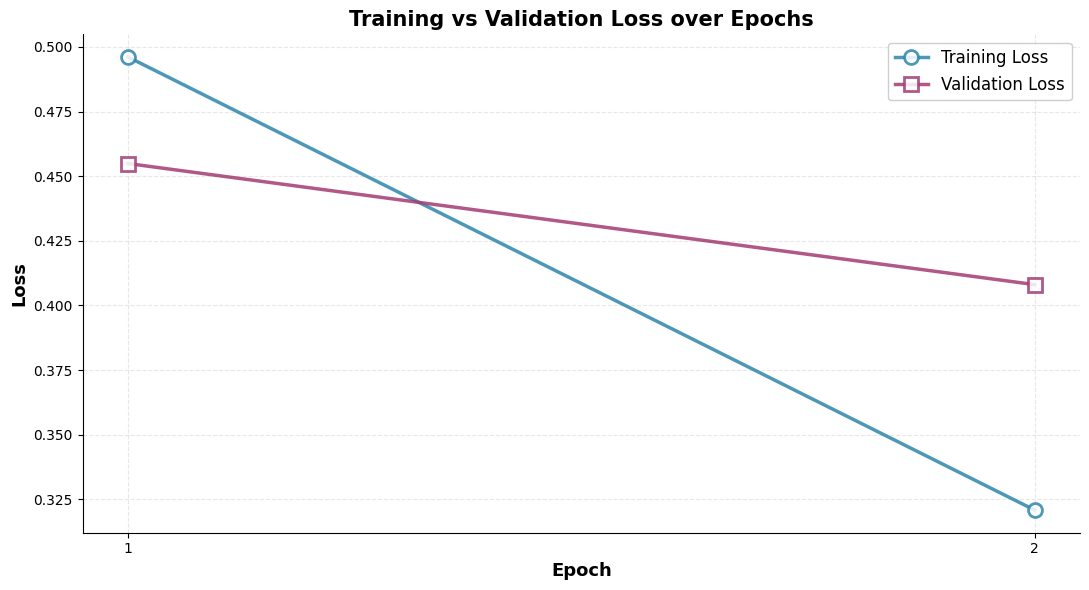

In [27]:
plt.figure(figsize=(11, 6))

# Extract training history from the best_trainer
history = trainer_best.state.log_history

# Separate train and eval logs 
train_losses = []
train_epochs = []
eval_losses = []
eval_epochs = []

for log in history:
    if "eval_loss" in log and "epoch" in log:
        eval_losses.append(log["eval_loss"])
        eval_epochs.append(log["epoch"])

        prev_train_logs = [
            h for h in history
            if "loss" in h and "epoch" in h and h["epoch"] <= log["epoch"]
        ]

        # Get training loss from the same log entry (at epoch end)
        if prev_train_logs:
            train_losses.append(prev_train_logs[-1]["loss"])
            train_epochs.append(log["epoch"])

plt.plot(train_epochs, train_losses,
         marker='o',
         label="Training Loss",
         linewidth=2.5,
         markersize=10,
         color='#2E86AB',
         alpha=0.85,
         markerfacecolor='white',
         markeredgewidth=2)

plt.plot(eval_epochs, eval_losses,
         marker='s',
         label="Validation Loss",
         linewidth=2.5,
         markersize=10,
         color="#A23B72",
         alpha=0.85,
         markerfacecolor='white',
         markeredgewidth=2)

plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.ylabel('Loss', fontsize=13, fontweight='bold')
plt.title("Training vs Validation Loss over Epochs", fontsize=15, fontweight='bold')
plt.legend(fontsize=12, loc="upper right", framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(eval_epochs)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Confusion Matrices Analysis

The confusion matrices for the **train, development, and test sets** show that the majority of predictions lie on the diagonal, indicating a high number of correct classifications.

Across all datasets, the number of errors (off-diagonal elements) is relatively small. More importantly, the errors are **balanced between False Positives and False Negatives**, meaning that the model does not favor one class over the other.

For example, on the test set:
- FP = 160 and FN = 160, showing perfectly symmetric behavior
- TN = TP = 2340, indicating equal performance on both classes

This confirms that the classifier handles both **negative and positive sentiment equally well**, without bias.

Additionally, the similarity between the confusion matrices of the training, development, and test sets suggests **strong generalization** and no significant overfitting.

Overall, the confusion matrices provide clear visual evidence that the fine-tuned **BERT + LoRA model** is both **accurate and well-balanced**.

CONFUSION MATRICES 



/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



TRAIN SET:
 Confusion Matrix:
[[17328   672]
 [  664 17336]]
 TP: 17336, TN: 17328, FP: 672, FN: 664
 Accuracy: 0.9629
 Misclassified: 1336 / 36000


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



DEV SET:
 Confusion Matrix:
[[4188  312]
 [ 287 4213]]
 TP: 4213, TN: 4188, FP: 312, FN: 287
 Accuracy: 0.9334
 Misclassified: 599 / 9000


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



TEST SET:
 Confusion Matrix:
[[2340  160]
 [ 160 2340]]
 TP: 2340, TN: 2340, FP: 160, FN: 160
 Accuracy: 0.9360
 Misclassified: 320 / 5000


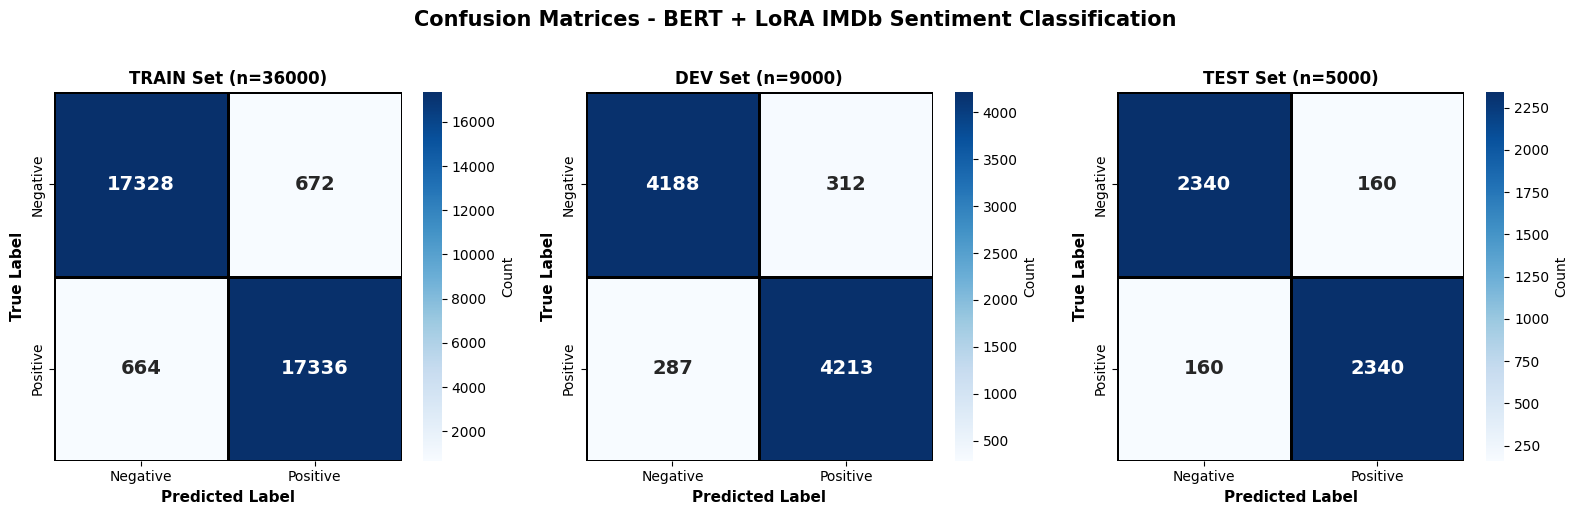

In [28]:
print("CONFUSION MATRICES ")
print("=" * 100 + "\n")

def plot_confusion_matrix(trainer, dataset, set_name, ax):
 """Plot confusion matrix for a specific dataset"""
 
 # Get predictions
 predictions = trainer.predict(dataset)
 logits = predictions.predictions
 labels = predictions.label_ids
 
 # Convert to class predictions
 pred_classes = np.argmax(logits, axis=1)
 
 # Compute confusion matrix
 cm = confusion_matrix(labels, pred_classes)
 
 # Plot
 sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
 xticklabels=['Negative', 'Positive'],
 yticklabels=['Negative', 'Positive'],
 cbar_kws={'label': 'Count'},
 ax=ax,
 annot_kws={'size': 14, 'weight': 'bold'},
 linewidths=2,
 linecolor='black')
 
 ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
 ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
 ax.set_title(f'{set_name.upper()} Set (n={len(labels)})', fontsize=12, fontweight='bold')
 
 # Print metrics
 tn, fp, fn, tp = cm.ravel()
 accuracy = (tp + tn) / (tp + tn + fp + fn)
 
 print(f"\n{set_name.upper()} SET:")
 print(f" Confusion Matrix:\n{cm}")
 print(f" TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
 print(f" Accuracy: {accuracy:.4f}")
 print(f" Misclassified: {fp + fn} / {len(labels)}")
 
 return cm

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot for each set
cm_train = plot_confusion_matrix(trainer_best, tokenized_dataset["train"], "train", axes[0])
cm_dev = plot_confusion_matrix(trainer_best, tokenized_dataset["validation"], "dev", axes[1])
cm_test = plot_confusion_matrix(trainer_best, tokenized_dataset["test"], "test", axes[2])

fig.suptitle('Confusion Matrices - BERT + LoRA IMDb Sentiment Classification', 
 fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


## Selection of Test Subset for LLM Evaluation (Bonus)

For the optional bonus experiment, we construct a **small representative subset** of the test set to evaluate a prompted Large Language Model (LLM).

### What we do

- Convert the test data into a pandas DataFrame
- Sample:
  - **5 negative reviews**
  - **5 positive reviews**
- Shuffle the combined subset to avoid ordering bias
- Map numeric labels to human-readable labels (Negative / Positive)

This results in a **balanced subset of 10 examples**, which ensures that:
- both sentiment classes are equally represented
- evaluation is not biased toward a specific class

---

### Why this is done

The assignment explicitly requires **indicative results on a small subset (e.g., 10 examples)**.

Using a balanced subset:
- allows fair comparison between classes
- makes manual inspection easier
- keeps API usage (or computation) minimal

---

### Output inspection

The selected examples are printed to:
- verify the correctness of sampling
- manually inspect the input that will be given to the LLM
- ensure diversity in the selected reviews



In [34]:
import pandas as pd

id2label = {0: "Negative", 1: "Positive"}

df_test = pd.DataFrame({
    "text": list(X_test),
    "label": list(y_test)
})

sample_df = pd.concat([
    df_test[df_test["label"] == 0].sample(n=5, random_state=42),
    df_test[df_test["label"] == 1].sample(n=5, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

sample_df["gold_label_name"] = sample_df["label"].map(id2label)

for i, row in sample_df.iterrows():
    print(f"\nEXAMPLE {i}")
    print("-" * 80)
    print(row["text"])


EXAMPLE 0
--------------------------------------------------------------------------------
Odd but wonderfully original movie. Genuinely frightening, creepy and ridiculous in equal measures. The setting of a high rise red brick apartment is a perfect backdrop for the haunting action. The thought of a secret sealed room in a place like this is good enough but when the lead naive couple start cleaning up the old bed they find in this room the scene is set for some classic chills. The cast is fantastic. Tanya Dempsey really gets to chew some scenery after being undervalued in other Full Moon films. Joe Estevez proves why brother Martin Sheen is so much bigger in Hollywood - his rolling eyes during the making the bed scene are really hilarious. Charles Band co-produced with Stuart Gordon and this really is an exceptional Full Moon/Darkwave release. Danny Draven also directed Hell Asylum with Dempsey.

EXAMPLE 1
------------------------------------------------------------------------------

## Bonus: LLM-Based Sentiment Classification on a Small Test Subset

As an optional bonus experiment, we evaluated a prompted Large Language Model (LLM) on a **small balanced subset of 10 test examples** from the IMDb dataset (5 Negative and 5 Positive reviews).

### What the code does

The code:
- stores the LLM responses for the 10 selected reviews
- maps the predicted labels from text form (`"Negative"` / `"Positive"`) to numeric labels
- compares the LLM predictions with the gold labels
- computes:
  - **Accuracy**
  - **Macro Precision**
  - **Macro Recall**
  - **Macro F1**
  - a full **classification report**

It also displays the review text together with:
- the true label
- the raw LLM response
- the final mapped prediction

---

## Results

The LLM achieved:

- **Accuracy:** 1.0000
- **Precision (macro):** 1.0000
- **Recall (macro):** 1.0000
- **F1-score (macro):** 1.0000

Per-class performance was also perfect:

- **Negative**: Precision = 1.00, Recall = 1.00, F1 = 1.00
- **Positive**: Precision = 1.00, Recall = 1.00, F1 = 1.00

---

## Interpretation

On this small subset, the LLM correctly classified **all 10 reviews**, achieving perfect performance.

This suggests that the LLM is capable of performing sentiment classification very effectively when prompted appropriately, at least on a limited number of examples.

However, this result should be interpreted with caution:

- the experiment uses only **10 test examples**
- therefore, the findings are **indicative rather than conclusive**
- such a small sample is not sufficient to draw strong statistical conclusions about overall LLM performance

---

## Final Takeaway

The bonus experiment shows that a prompted LLM can perform extremely well on a small sentiment classification sample, even without task-specific fine-tuning in the standard supervised sense.

Nevertheless, because the evaluation is based on only 10 examples, the result should be treated as a **demonstration of potential**, not as a definitive comparison with the fully trained BERT-based classifier.

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

manual_responses = [
    "Positive",  
    "Negative",  
    "Positive",  
    "Negative",  
    "Positive",  
    "Negative",  
    "Positive",  
    "Negative",  
    "Negative",  
    "Positive"   
]

label2id = {"Negative": 0, "Positive": 1}

sample_df["llm_raw_response"] = manual_responses
sample_df["llm_pred"] = sample_df["llm_raw_response"].map(label2id)
sample_df["llm_pred_name"] = sample_df["llm_pred"].map(id2label)

y_true = sample_df["label"]
y_pred = sample_df["llm_pred"]

print(" LLM EXPERIMENT RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision (macro): {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1 (macro): {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=["Negative", "Positive"],
    zero_division=0
))

sample_df[["text", "gold_label_name", "llm_raw_response", "llm_pred_name"]]

BONUS LLM EXPERIMENT RESULTS
Accuracy: 1.0000
Precision (macro): 1.0000
Recall (macro): 1.0000
F1 (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         5
    Positive       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



,text,gold_label_name,llm_raw_response,llm_pred_name
0,Odd but wonderfully original movie. Genuinely ...,Positive,Positive,Positive
1,USA's AZN TV purchased the rights to this film...,Negative,Negative,Negative
2,This is a movie that plays to everyone's emoti...,Positive,Positive,Positive
3,"The acting is good, the women are beautiful, a...",Negative,Negative,Negative
4,"***SPOILERS*** ***SPOILERS*** Wow, what a pred...",Positive,Positive,Positive
5,The Good Earth is not a great film by any mean...,Negative,Negative,Negative
6,I just can't understand why people are surpris...,Positive,Positive,Positive
7,This movie is truly boring. It was banned in C...,Negative,Negative,Negative
8,Considering that they wanted to do a vampire m...,Negative,Negative,Negative
9,"""Murder by Numbers"" stars Ryan Gosling and Mic...",Positive,Positive,Positive


### Final Model Comparison

1. Transformer vs Baselines:

94.85% improvement over Majority Baseline in F1-Macro (0.9376 vs 0.3331)
10.96% improvement over Logistic Regression in F1-Macro (0.9376 vs 0.8440)
Demonstrates superior capability in learning complex sentiment patterns

2. BERT + LoRA significantly outperforms all previous deep learning models:

4-6% improvement in F1-Macro over CNN/RNN/MLP
PR-AUC advantage: 0.9832 vs 0.9532-0.9605 (superior ranking ability)
Perfect balance: Precision = Recall = F1 (0.9376 across all metrics)


Pre-trained Knowledge: BERT leverages 110M parameters pre-trained on massive text corpus

CNN/RNN/MLP trained from scratch on limited IMDb data
Transfer learning provides significant boost


Attention Mechanisms: Captures long-range dependencies better than RNNs

Transformer attention > RNN sequential processing for context understanding
Better handling of negations ("not good" vs "good")


Contextual Word Embeddings: BERT generates context-aware representations

vs fixed embeddings used by CNN/RNN/MLP
Same word has different embeddings based on context


Parameter Efficiency with LoRA: Fine-tuning only 0.27% of parameters

Achieves better performance than fully trained smaller models
Faster training and inference than full fine-tuning



| Model | Accuracy | F1-Macro | Precision | Recall | PR-AUC (Macro) |
|---|---|---|---|---|---|
| Majority Baseline | 0.4994 | 0.3331 | 0.2497 | 0.5000 | 0.5000 |
| Logistic Regression | 0.8440 | 0.8440 | 0.8441 | 0.8440 | 0.9243 |
| Best MLP | 0.8938 | 0.8938 | 0.8944 | 0.8938 | 0.9605 |
| Best RNN (BiLSTM+Attention) | 0.8942 | 0.8941 | 0.8954 | 0.8942 | 0.9561 |
| Best CNN (Max-Pooling) | 0.8844 | 0.8844 | 0.8876 | 0.8844 | 0.9532 |
| BERT + LoRA (Transformer) | 0.9360 | 0.9360 | 0.9360 | 0.9360 | 0.9835 |